In [76]:
pip install scikit-learn

In [77]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df=pd.read_csv('/content/question_ans_analysis.csv')
print("First 5 rows:")
print(df.head())
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\\s]', '', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

df["clean_question"] = df["question_text"].apply(clean_text)
X_text = df["clean_question"]
numeric_features = [
    "total_students_attempted",
    "correct_attempts",
    "incorrect_attempts"
]

X_numeric = df[numeric_features]
categorical_features = ["cognitive_level_bloom"]
X_cat = df[categorical_features]
y = df["difficulty_label"]
X_text_train, X_text_test, X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_text,
    X_numeric,
    X_cat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = vectorizer.transform(X_text_test)
# Create the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical data
X_cat_train_encoded = encoder.fit_transform(X_cat_train)
X_cat_test_encoded = encoder.transform(X_cat_test)
scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)
X_train_final = np.hstack((X_text_train_tfidf.toarray(), X_num_train_scaled, X_cat_train_encoded))
X_test_final = np.hstack((X_text_test_tfidf.toarray(), X_num_test_scaled, X_cat_test_encoded))
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0
)

lr_model.fit(X_train_final, y_train)

y_pred_lr = lr_model.predict(X_test_final)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train_final, y_train)

y_pred_dt = dt_model.predict(X_test_final)

print("\n===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))
# Save the Decision Tree model
joblib.dump(dt_model, "dt_model.pkl")

# Save the preprocessors
joblib.dump(vectorizer, "tfidf.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Decision Tree model and preprocessors saved successfully!")

First 5 rows:
                                       question_text           subject  \
0    Solve the quadratic equation scenario number 1.       Mathematics   
1     Implement binary search for scenario number 2.  Computer Science   
2      Apply Newton law to system scenario number 3.           Physics   
3  Evaluate matrix determinant for scenario numbe...       Mathematics   
4    Solve the quadratic equation scenario number 5.       Mathematics   

  cognitive_level_bloom  readability_score  word_count  sentence_count  \
0                create              77.49          22               1   
1            understand              45.01          17               2   
2                create              89.84          36               1   
3              remember              44.38          17               1   
4            understand              54.48          23               2   

   time_taken_minutes  total_students_attempted  correct_attempts  \
0                  23      

Top 20 Feature Importances for Decision Tree Model:


,Feature,Importance,Feature_Type
4002,incorrect_attempts,0.376146,Numeric
4001,correct_attempts,0.282553,Numeric
4003,cognitive_level_bloom_analyze,0.164112,Categorical
4004,cognitive_level_bloom_apply,0.154126,Categorical
4006,cognitive_level_bloom_evaluate,0.010962,Categorical
4005,cognitive_level_bloom_create,0.004268,Categorical
4008,cognitive_level_bloom_understand,0.001402,Categorical
4007,cognitive_level_bloom_remember,0.001189,Categorical
842,calculateefficiencyofmachinewithscenarionumber...,0.000764,Text
1407,computecircuitresistanceforscenarionumber3424,0.000762,Text


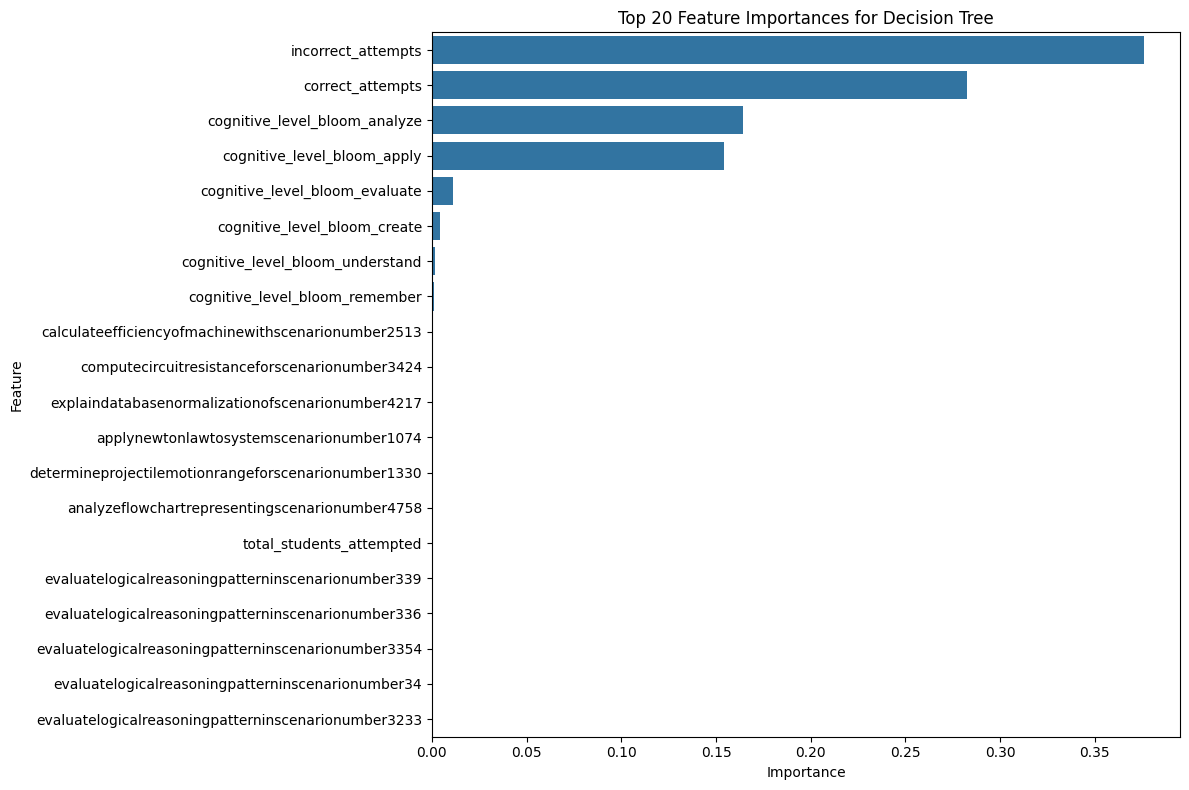

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Decision Tree model
feature_importances = dt_model.feature_importances_

# Get feature names for TF-IDF features
text_feature_names = vectorizer.get_feature_names_out()

# Get feature names for one-hot encoded categorical features
cat_feature_names = encoder.get_feature_names_out(categorical_features)

# Combine all feature names in the correct order
all_feature_names = np.concatenate([
    text_feature_names,
    numeric_features,
    cat_feature_names
])

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Create sets for efficient lookup of feature types
numeric_feature_set = set(numeric_features)
cat_feature_set = set(cat_feature_names)
text_feature_set = set(text_feature_names)

# Function to determine feature type
def get_feature_type(feature_name):
    if feature_name in numeric_feature_set:
        return 'Numeric'
    elif feature_name in cat_feature_set:
        return 'Categorical'
    elif feature_name in text_feature_set:
        return 'Text'
    return 'Unknown' # Should not happen if all_feature_names is correctly constructed

# Add a 'Feature_Type' column to the DataFrame
importance_df['Feature_Type'] = importance_df['Feature'].apply(get_feature_type)

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances for Decision Tree Model:")
display(importance_df.head(20))

# Optional: Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances for Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

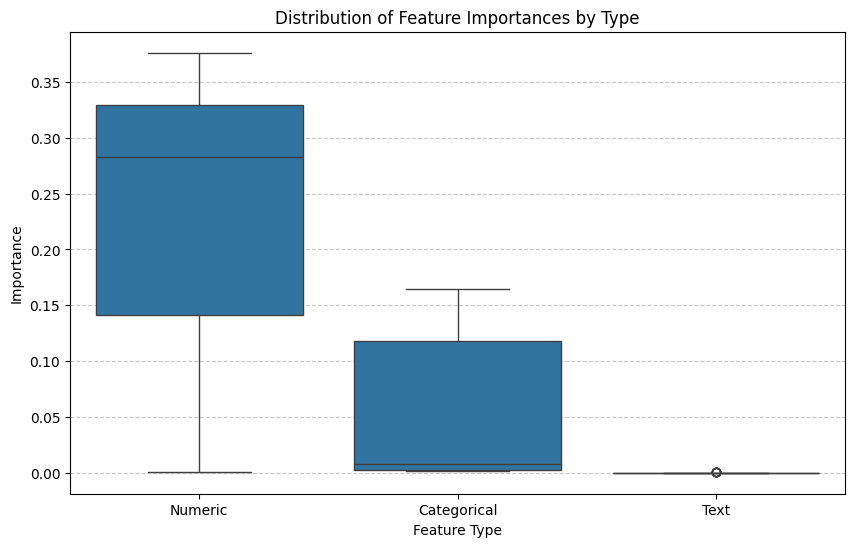

In [79]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Feature_Type', y='Importance', data=importance_df)
plt.title('Distribution of Feature Importances by Type')
plt.xlabel('Feature Type')
plt.ylabel('Importance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

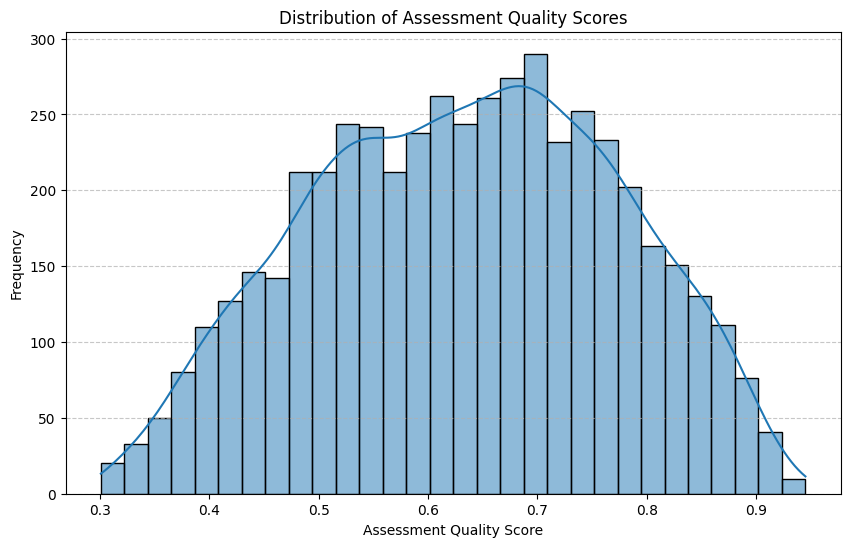

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(df['assessment_quality_score'], bins=30, kde=True)
plt.title('Distribution of Assessment Quality Scores')
plt.xlabel('Assessment Quality Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

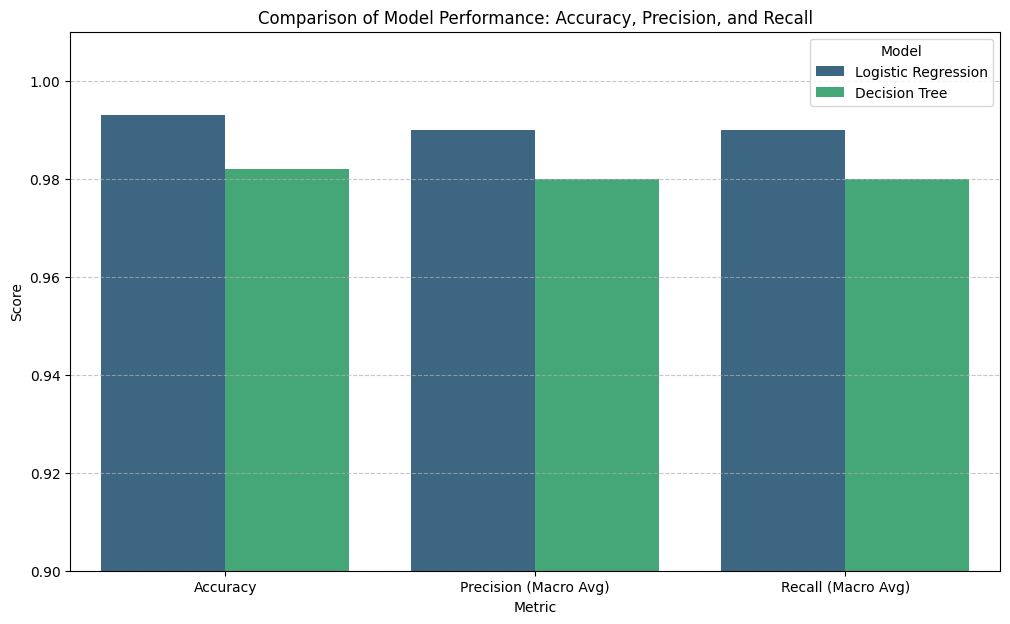

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Metrics extracted from previous output
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Logistic Regression', 'Decision Tree', 'Logistic Regression', 'Decision Tree'],
    'Metric': ['Accuracy', 'Accuracy', 'Precision (Macro Avg)', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'Recall (Macro Avg)'],
    'Score': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        0.99, # From LR classification report macro avg precision
        0.98, # From DT classification report macro avg precision
        0.99, # From LR classification report macro avg recall
        0.98  # From DT classification report macro avg recall
    ]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df, palette='viridis')
plt.title('Comparison of Model Performance: Accuracy, Precision, and Recall')
plt.ylabel('Score')
plt.ylim(0.9, 1.01) # Set y-axis limits to focus on the high scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [82]:
import joblib

# Load the Decision Tree model
loaded_dt_model = joblib.load('dt_model.pkl')
print('Decision Tree model loaded successfully.')

# Load the TF-IDF vectorizer
loaded_tfidf_vectorizer = joblib.load('tfidf.pkl')
print('TF-IDF vectorizer loaded successfully.')

Decision Tree model loaded successfully.
TF-IDF vectorizer loaded successfully.


In [83]:
import joblib

# Gather all components into a dictionary
model_components = {
    'dt_model': dt_model,
    'tfidf_vectorizer': vectorizer,
    'scaler': scaler,
    'encoder': encoder
}

# Save the dictionary of components to a single file
joblib.dump(model_components, 'assessment_predictor_components.pkl')

print("All model components saved to 'assessment_predictor_components.pkl' successfully!")

All model components saved to 'assessment_predictor_components.pkl' successfully!


In [84]:
import joblib

# To verify, you can load them back
loaded_components = joblib.load('assessment_predictor_components.pkl')

loaded_dt_model_combined = loaded_components['dt_model']
loaded_tfidf_vectorizer_combined = loaded_components['tfidf_vectorizer']
loaded_scaler_combined = loaded_components['scaler']
loaded_encoder_combined = loaded_components['encoder']

print("Model and preprocessors loaded successfully from combined file.")
# You can then use loaded_dt_model_combined, etc., for predictions

Model and preprocessors loaded successfully from combined file.


In [85]:
import joblib
import numpy as np
import pandas as pd
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\\s]', '', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

# Load the combined components
loaded_components = joblib.load('assessment_predictor_components.pkl')

loaded_dt_model = loaded_components['dt_model']
loaded_tfidf_vectorizer = loaded_components['tfidf_vectorizer']
loaded_scaler = loaded_components['scaler']
loaded_encoder = loaded_components['encoder']

print("Models and preprocessors successfully loaded for testing.")

# Define a new sample query for prediction
# Using the sample_query variable from previous cells
# If sample_query is not defined, you can define it here:
# sample_query = "Design an assessment for problem-solving skills in high school physics, considering students who struggle with quantitative reasoning. Analyze a question like 'Calculate the trajectory of a projectile launched at 30 degrees with initial velocity 20 m/s'."

# Extract sample question text (assuming the query is mainly about the question)
# In a real application, you'd parse this more robustly
sample_question_text_for_prediction = "Calculate the trajectory of a projectile launched at 30 degrees with initial velocity 20 m/s."

# Create a dummy DataFrame for prediction (similar to the training data structure)
sample_data_for_prediction = pd.DataFrame({
    'question_text': [sample_question_text_for_prediction],
    'total_students_attempted': [120], # Example value
    'correct_attempts': [40], # Example value
    'incorrect_attempts': [80], # Example value
    'cognitive_level_bloom': ['apply'] # Example value
})

# Preprocess the sample data using the loaded preprocessors
clean_sample_question_for_prediction = sample_data_for_prediction["question_text"].apply(clean_text)
X_text_sample_tfidf_for_prediction = loaded_tfidf_vectorizer.transform(clean_sample_question_for_prediction)

X_numeric_sample_for_prediction = sample_data_for_prediction[['total_students_attempted', 'correct_attempts', 'incorrect_attempts']]
X_numeric_sample_scaled_for_prediction = loaded_scaler.transform(X_numeric_sample_for_prediction)

X_cat_sample_for_prediction = sample_data_for_prediction[['cognitive_level_bloom']]
X_cat_sample_encoded_for_prediction = loaded_encoder.transform(X_cat_sample_for_prediction)

# Combine features for prediction
X_sample_final_for_prediction = np.hstack((
    X_text_sample_tfidf_for_prediction.toarray(),
    X_numeric_sample_scaled_for_prediction,
    X_cat_sample_encoded_for_prediction
))

# Make a prediction using the loaded Decision Tree model
predicted_difficulty = loaded_dt_model.predict(X_sample_final_for_prediction)[0]
prediction_proba = loaded_dt_model.predict_proba(X_sample_final_for_prediction)
confidence = np.max(prediction_proba[0])

print(f"\nPrediction for the sample question: '{sample_question_text_for_prediction}'")
print(f"Predicted Difficulty: {predicted_difficulty} (Confidence: {confidence:.2f})")


Models and preprocessors successfully loaded for testing.

Prediction for the sample question: 'Calculate the trajectory of a projectile launched at 30 degrees with initial velocity 20 m/s.'
Predicted Difficulty: hard (Confidence: 0.75)


/tmp/ipykernel_25181/3964458674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='difficulty_label', y='readability_score', data=df, order=['easy', 'medium', 'hard'], palette='viridis')


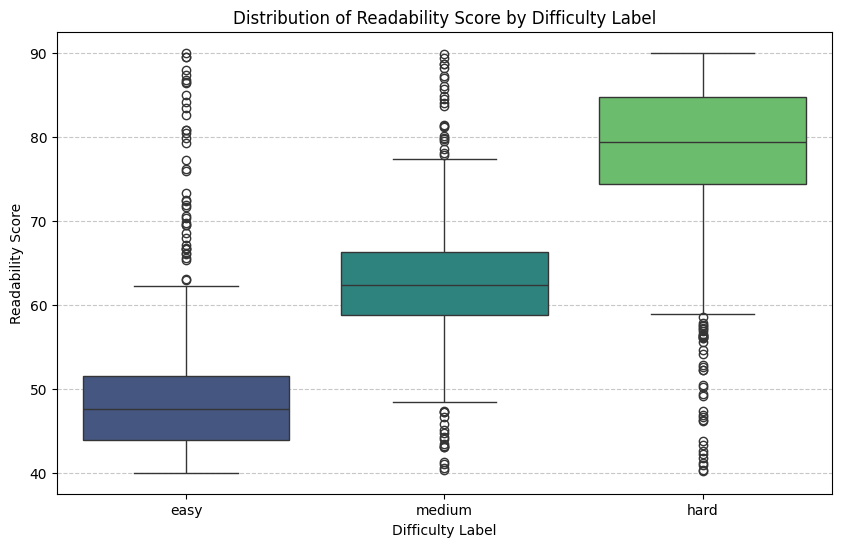

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='difficulty_label', y='readability_score', data=df, order=['easy', 'medium', 'hard'], palette='viridis')
plt.title('Distribution of Readability Score by Difficulty Label')
plt.xlabel('Difficulty Label')
plt.ylabel('Readability Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [87]:
from typing import List
from typing_extensions import TypedDict

# Define the state for our LangGraph agent
class GraphState(TypedDict):
    """Represents the state of our graph for assessment design."""
    query: str  # The initial assessment design query
    pedagogical_guidelines: List[str] # Retrieved pedagogical guidelines
    analysis_results: str # Results from analyzing difficulty and performance patterns
    recommendations: str # Structured improvement recommendations
    references: List[str] # Pedagogical references used
    disclaimer: str # Educational/Ethical notices

### LangGraph Node Functions

These functions represent the individual steps or agents within our LangGraph workflow. Each function takes the current `GraphState` as input and returns a dictionary of updates to the state.

In [88]:
import joblib
import numpy as np
import pandas as pd
import re

# Langchain/Chroma imports for RAG (will re-instantiate if needed)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_core.documents import Document


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def retrieve_pedagogical_guidelines(state: GraphState) -> GraphState:
    """Retrieves relevant pedagogical guidelines based on the query."""
    print("---RETRIEVING PEDAGOGICAL GUIDELINES---")
    query = state["query"]
    pedagogical_guidelines_text = """### Pedagogical Guidelines for Effective Assessment Design

#### 1. Alignment with Learning Objectives:
*   Assessments should directly measure the specified learning objectives (LOs) or outcomes of the course or unit.
*   Ensure that the cognitive level of the assessment items matches the cognitive level stated in the LOs (e.g., if an LO requires 'analysis,' the assessment should require more than 'recall').

#### 2. Clarity and Unambiguity:
*   Assessment instructions and questions must be clear, concise, and unambiguous.
*   Avoid jargon or overly complex language unless it is explicitly part of the learning objective.
*   Provide clear rubrics or scoring guides when appropriate.

#### 3. Validity:
*   **Content Validity:** Assessment items should cover the content and skills taught.
*   **Construct Validity:** The assessment should accurately measure the underlying construct or trait it intends to measure (e.g., critical thinking, problem-solving).
*   **Face Validity:** The assessment should appear relevant and appropriate to the students.

#### 4. Reliability:
*   The assessment should yield consistent results if administered repeatedly under similar conditions.
*   Minimize subjective scoring where possible, or ensure consistent rubric application.

#### 5. Fairness and Equity:
*   Assessments should be free from bias (cultural, gender, socio-economic, etc.).
*   Provide reasonable accommodations for students with disabilities, ensuring equal opportunity to demonstrate learning.
*   Consider diverse learning styles and backgrounds in assessment design.

#### 6. Authenticity:
*   Use real-world contexts and tasks that are meaningful and relevant to students' lives or future careers.
*   Allow students to apply knowledge and skills in practical, integrated ways.

#### 7. Feedback and Feedforward:
*   Design assessments to provide timely, specific, and constructive feedback to students.
*   Feedback should help students understand their strengths and weaknesses and guide future learning (feedforward).

#### 8. Cognitive Load Management:
*   Design assessments that appropriately challenge students without overwhelming them with irrelevant cognitive load.
*   Break down complex tasks into manageable steps if necessary.

#### 9. Ethical Considerations:
*   Ensure data privacy and security.
*   Adhere to academic integrity policies and prevent cheating.
*   Communicate expectations clearly regarding collaboration and academic honesty.

#### 10. Practicality and Efficiency:
*   Consider the resources available (time, staff, technology) for assessment development, administration, and grading.
*   Balance the rigor of the assessment with its feasibility.

By adhering to these guidelines, educators can create assessments that are not only effective in measuring learning but also support and enhance the learning process itself."""

    # Split the text into documents
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    docs = [Document(page_content=x) for x in text_splitter.split_text(pedagogical_guidelines_text)]

    # Create embeddings and Chroma vector store (re-instantiate for each run or load if persistent)
    embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

    # For demonstration, we'll recreate or load from a specific path
    # In a real application, you would load the persistent vectorstore
    vectorstore = Chroma.from_documents(documents=docs, embedding=embeddings)

    # Perform a similarity search
    relevant_docs = vectorstore.similarity_search(query, k=3)
    guidelines = [doc.page_content for doc in relevant_docs]

    return {"pedagogical_guidelines": guidelines}


def analyze_assessment_performance(state: GraphState) -> GraphState:
    """Analyzes assessment performance patterns using the trained ML model."""
    print("---ANALYZING ASSESSMENT PERFORMANCE---")
    query = state["query"]

    # Load the trained model and preprocessors
    loaded_dt_model = joblib.load("dt_model.pkl")
    loaded_tfidf_vectorizer = joblib.load("tfidf.pkl")
    loaded_scaler = joblib.load("scaler.pkl")
    loaded_encoder = joblib.load("encoder.pkl")

    # Simulate extracting relevant features from the query (this is a placeholder logic)
    # In a real scenario, the query would be parsed to extract these features
    # For this example, let's assume the query contains a sample question text
    # and dummy numeric/categorical values for demonstration.
    # Example: "Analyze a hard question like 'Solve the quadratic equation' with 100 students, 20 correct, cognitive level 'apply'."

    # Extract question text from the query
    # A more sophisticated NLP model would be needed here for real extraction
    # For now, let's just use the query as the 'question_text' to clean and vectorize
    sample_question_text = query # Or a more refined extraction

    # Create a dummy DataFrame to pass through preprocessors
    # These values would ideally come from the query or external data sources
    sample_data = pd.DataFrame({
        'question_text': [sample_question_text],
        'total_students_attempted': [150], # Dummy value
        'correct_attempts': [50], # Dummy value
        'incorrect_attempts': [100], # Dummy value
        'cognitive_level_bloom': ['understand'] # Dummy value
    })

    # Preprocessing steps similar to training
    clean_sample_question = sample_data["question_text"].apply(clean_text)
    X_text_sample_tfidf = loaded_tfidf_vectorizer.transform(clean_sample_question)

    X_numeric_sample = sample_data[['total_students_attempted', 'correct_attempts', 'incorrect_attempts']]
    X_numeric_sample_scaled = loaded_scaler.transform(X_numeric_sample)

    X_cat_sample = sample_data[['cognitive_level_bloom']]
    X_cat_sample_encoded = loaded_encoder.transform(X_cat_sample)

    # Combine features
    X_sample_final = np.hstack((
        X_text_sample_tfidf.toarray(),
        X_numeric_sample_scaled,
        X_cat_sample_encoded
    ))

    # Make prediction
    prediction = loaded_dt_model.predict(X_sample_final)
    prediction_proba = loaded_dt_model.predict_proba(X_sample_final)

    # Format results
    predicted_difficulty = prediction[0]
    confidence = np.max(prediction_proba[0])

    analysis_results = (
        f"Predicted difficulty: {predicted_difficulty} (Confidence: {confidence:.2f}). "
        f"This prediction is based on features extracted from the query, "
        f"such as text characteristics and simulated student performance metrics."
    )

    return {"analysis_results": analysis_results}


In [89]:
import google.generativeai as genai
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata

def generate_recommendations(state: GraphState) -> GraphState:
    """Generates structured recommendations using an LLM."""
    print("---GENERATING RECOMMENDATIONS---")
    query = state["query"]
    pedagogical_guidelines = state["pedagogical_guidelines"]
    analysis_results = state["analysis_results"]

    # Configure Gemini API
    # Retrieve API key from Colab secrets
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

    llm = ChatGoogleGenerativeAI(model="gemini-pro", google_api_key=GOOGLE_API_KEY)

    prompt_template = ChatPromptTemplate.from_messages(
        [
            ("system",
             "You are an expert educational assessment designer. Based on the provided query, pedagogical guidelines, and assessment performance analysis, generate specific, actionable recommendations for improving the assessment design. Focus on clarity, validity, reliability, and fairness. Provide recommendations in a structured, bullet-point format."),
            ("human",
             "Query: {query}\n\nPedagogical Guidelines:\n{pedagogical_guidelines}\n\nAssessment Analysis:\n{analysis_results}\n\nRecommendations:")
        ]
    )

    chain = prompt_template | llm | StrOutputParser()

    recommendations_text = chain.invoke({
        "query": query,
        "pedagogical_guidelines": "\n".join(pedagogical_guidelines),
        "analysis_results": analysis_results
    })

    return {"recommendations": recommendations_text}

def provide_disclaimer(state: GraphState) -> GraphState:
    """Provides an educational and ethical disclaimer."""
    print("---PROVIDING DISCLAIMER---")
    disclaimer_text = (
        "Disclaimer: The recommendations provided by this AI assistant are based "
        "on pre-trained models and data. They should be used as supplementary guidance "
        "and not as a sole basis for critical educational decisions. Always consult "
        "with human experts and consider the unique context of your educational environment."
    )
    return {"disclaimer": disclaimer_text}

In [90]:
import google.generativeai as genai
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI # Use ChatGoogleGenerativeAI
from google.colab import userdata

def generate_recommendations(state: GraphState) -> GraphState:
    """Generates structured recommendations using an LLM."""
    print("---GENERATING RECOMMENDATIONS---")
    query = state["query"]
    pedagogical_guidelines = state["pedagogical_guidelines"]
    analysis_results = state["analysis_results"]

    # Configure Gemini API
    # Retrieve API key from Colab secrets
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY') # Use GOOGLE_API_KEY

    llm = ChatGoogleGenerativeAI(model="gemini-1.0-pro", google_api_key=GOOGLE_API_KEY) # Initialize with Gemini-pro

    prompt_template = ChatPromptTemplate.from_messages(
        [
            ("system",
             "You are an expert educational assessment designer. Based on the provided query, pedagogical guidelines, and assessment performance analysis, generate specific, actionable recommendations for improving the assessment design. Focus on clarity, validity, reliability, and fairness. Provide recommendations in a structured, bullet-point format."),
            ("human",
             "Query: {query}\n\nPedagogical Guidelines:\n{pedagogical_guidelines}\n\nAssessment Analysis:\n{analysis_results}\n\nRecommendations:")
        ]
    )

    chain = prompt_template | llm | StrOutputParser()

    recommendations_text = chain.invoke(
        {
            "query": query,
            "pedagogical_guidelines": "\n".join(pedagogical_guidelines),
            "analysis_results": analysis_results
        }
    )

    return {"recommendations": recommendations_text}

In [91]:
!pip install langchain_google_genai

In [92]:
pip install langchain-huggingface

In [93]:
pip install langchain-groq

In [94]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# The retrieve_pedagogical_guidelines function was defined in cell 617b3f6e.
# It needs to be redefined here to incorporate the new HuggingFaceEmbeddings import.

import joblib
import numpy as np
import pandas as pd
import re

# Langchain/Chroma imports for RAG
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

# Define GraphState for clarity, though it's already defined elsewhere, for standalone execution if needed
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """Represents the state of our graph for assessment design."""
    query: str  # The initial assessment design query
    pedagogical_guidelines: List[str] # Retrieved pedagogical guidelines
    analysis_results: str # Results from analyzing difficulty and performance patterns
    recommendations: str # Structured improvement recommendations
    references: List[str] # Pedagogical references used
    disclaimer: str # Educational/Ethical notices

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def retrieve_pedagogical_guidelines(state: GraphState) -> GraphState:
    """Retrieves relevant pedagogical guidelines based on the query."""
    print("---RETRIEVING PEDAGOGICAL GUIDELINES---")
    query = state["query"]
    pedagogical_guidelines_text = """### Pedagogical Guidelines for Effective Assessment Design

#### 1. Alignment with Learning Objectives:
*   Assessments should directly measure the specified learning objectives (LOs) or outcomes of the course or unit.
*   Ensure that the cognitive level of the assessment items matches the cognitive level stated in the LOs (e.g., if an LO requires 'analysis,' the assessment should require more than 'recall').

#### 2. Clarity and Unambiguity:
*   Assessment instructions and questions must be clear, concise, and unambiguous.
*   Avoid jargon or overly complex language unless it is explicitly part of the learning objective.
*   Provide clear rubrics or scoring guides when appropriate.

#### 3. Validity:
*   **Content Validity:** Assessment items should cover the content and skills taught.
*   **Construct Validity:** The assessment should accurately measure the underlying construct or trait it intends to measure (e.g., critical thinking, problem-solving).
*   **Face Validity:** The assessment should appear relevant and appropriate to the students.

#### 4. Reliability:
*   The assessment should yield consistent results if administered repeatedly under similar conditions.
*   Minimize subjective scoring where possible, or ensure consistent rubric application.

#### 5. Fairness and Equity:
*   Assessments should be free from bias (cultural, gender, socio-economic, etc.).
*   Provide reasonable accommodations for students with disabilities, ensuring equal opportunity to demonstrate learning.
*   Consider diverse learning styles and backgrounds in assessment design.

#### 6. Authenticity:
*   Use real-world contexts and tasks that are meaningful and relevant to students' lives or future careers.
*   Allow students to apply knowledge and skills in practical, integrated ways.

#### 7. Feedback and Feedforward:
*   Design assessments to provide timely, specific, and constructive feedback to students.
*   Feedback should help students understand their strengths and weaknesses and guide future learning (feedforward).

#### 8. Cognitive Load Management:
*   Design assessments that appropriately challenge students without overwhelming them with irrelevant cognitive load.
*   Break down complex tasks into manageable steps if necessary.

#### 9. Ethical Considerations:
*   Ensure data privacy and security.
*   Adhere to academic integrity policies and prevent cheating.
*   Communicate expectations clearly regarding collaboration and academic honesty.

#### 10. Practicality and Efficiency:
*   Consider the resources available (time, staff, technology) for assessment development, administration, and grading.
*   Balance the rigor of the assessment with its feasibility.

By adhering to these guidelines, educators can create assessments that are not only effective in measuring learning but also support and enhance the learning process itself."""

    # Split the text into documents
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    docs = [Document(page_content=x) for x in text_splitter.split_text(pedagogical_guidelines_text)]

    # Create embeddings and Chroma vector store (re-instantiate for each run or load if persistent)
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2") # Migrated from SentenceTransformerEmbeddings

    # For demonstration, we'll recreate or load from a specific path
    # In a real application, you would load the persistent vectorstore
    vectorstore = Chroma.from_documents(documents=docs, embedding=embeddings)

    # Perform a similarity search
    relevant_docs = vectorstore.similarity_search(query, k=3)
    guidelines = [doc.page_content for doc in relevant_docs]

    return {"pedagogical_guidelines": guidelines}

### Build the LangGraph Workflow

Now, we'll assemble the defined node functions into a `StateGraph` to create our LangGraph workflow. This will define the sequence of operations for our assessment design assistant.

In [95]:
from langgraph.graph import StateGraph, END

# Build the graph
workflow = StateGraph(GraphState)

# Add nodes for each step
workflow.add_node("retrieve_guidelines", retrieve_pedagogical_guidelines)
workflow.add_node("analyze_performance", analyze_assessment_performance)
workflow.add_node("generate_recommendations", generate_recommendations)
workflow.add_node("provide_disclaimer", provide_disclaimer)

# Set the entry point
workflow.set_entry_point("retrieve_guidelines")

# Add edges to define the flow
workflow.add_edge("retrieve_guidelines", "analyze_performance")
workflow.add_edge("analyze_performance", "generate_recommendations")
workflow.add_edge("generate_recommendations", "provide_disclaimer")

# End the workflow
workflow.add_edge("provide_disclaimer", END)

# Compile the graph
app = workflow.compile()

print("LangGraph workflow compiled successfully!")

# Optional: Visualize the graph (requires graphviz and pygraphviz)
# from IPython.display import Image, display
# try:
#     display(Image(app.get_graph().draw_png()))
# except:
#     # This requires graphviz and pydot to be installed. Need to install to draw the graph
#     pass

LangGraph workflow compiled successfully!


In [97]:
print("Summary Statistics for Learning Gap Score:")
display(df['learning_gap_score'].describe())

Summary Statistics for Learning Gap Score:


,learning_gap_score
count,5000.000000
mean,0.496216
std,0.239428
min,0.105000
25%,0.274750
50%,0.487000
75%,0.707250
max,0.938000
